# Titanic 데이터 분석

## 분석 목표
타이타닉 승객 데이터를 살펴보고, 승객의 특징과 생존 여부 사이에 어떤 관계가 있는지 분석한다.
Sleep 데이터 분석에서 배운 데이터 확인, 전처리, 시각화 방법을 적용하고 주요 관찰 결과를 정리한다.


In [130]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

In [131]:
with open("titanic_raw.json", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)

In [132]:
df.head()

,Age,Cabin,Life Boat,Name,No of Parents or Children on Board,No of Siblings or Spouses on Board,Passenger Class,Passenger Fare,Port of Embarkation,Sex,Survived,Ticket Number
0,29,B5,2,"Allen, Miss. Elisabeth Walton",0,0,First,211.3375,Southampton,Female,Yes,24160
1,0.9167,C22 C26,11,"Allison, Master. Hudson Trevor",2,1,First,151.55,Southampton,Male,Yes,113781
2,2,C22 C26,,"Allison, Miss. Helen Loraine",2,1,First,151.55,Southampton,Female,No,113781
3,30,C22 C26,,"Allison, Mr. Hudson Joshua Creighton",2,1,First,151.55,Southampton,Male,No,113781
4,25,C22 C26,,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",2,1,First,151.55,Southampton,Female,No,113781


In [133]:
df.tail()

,Age,Cabin,Life Boat,Name,No of Parents or Children on Board,No of Siblings or Spouses on Board,Passenger Class,Passenger Fare,Port of Embarkation,Sex,Survived,Ticket Number
1304,14.5,C85,,"Zabour, Miss. Hileni",0,1,Third,14.4542,Cherbourg,Female,No,2665
1305,,D47,,"Zabour, Miss. Thamine",0,1,Third,14.4542,Cherbourg,Female,No,2665
1306,26.5,G43,,"Zakarian, Mr. Mapriededer",0,0,Third,7.225,Cherbourg,Male,No,2656
1307,27,E14,,"Zakarian, Mr. Ortin",0,0,Third,7.225,Cherbourg,Male,No,2670
1308,29,D21,,"Zimmerman, Mr. Leo",0,0,Third,7.875,Southampton,Male,No,315082


In [134]:
print(f"이 데이터셋의 구조는 {df.shape}")

이 데이터셋의 구조는 (1309, 12)


In [135]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Age                                 1309 non-null   object
 1   Cabin                               1309 non-null   str   
 2   Life Boat                           1309 non-null   object
 3   Name                                1309 non-null   str   
 4   No of Parents or Children on Board  1309 non-null   int64 
 5   No of Siblings or Spouses on Board  1309 non-null   int64 
 6   Passenger Class                     1309 non-null   str   
 7   Passenger Fare                      1309 non-null   object
 8   Port of Embarkation                 1309 non-null   str   
 9   Sex                                 1309 non-null   str   
 10  Survived                            1309 non-null   str   
 11  Ticket Number                       1309 non-null   object
dtypes: 

* Observation: tail로 데이터를 봤을때 1305번째인덱스 나이 셀이 비여있는데 결측치가 없다.<br>또한 나이 데이터 타입이 object이므로 숫자 데이터로 변형해야함(추가로 나머지 컬럼도) 

In [136]:
df["Age"] = pd.to_numeric(df["Age"],errors="coerce")
df["Passenger Fare"] = pd.to_numeric(df["Passenger Fare"],errors="coerce")

In [137]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 1046 non-null   float64
 1   Cabin                               1309 non-null   str    
 2   Life Boat                           1309 non-null   object 
 3   Name                                1309 non-null   str    
 4   No of Parents or Children on Board  1309 non-null   int64  
 5   No of Siblings or Spouses on Board  1309 non-null   int64  
 6   Passenger Class                     1309 non-null   str    
 7   Passenger Fare                      1308 non-null   float64
 8   Port of Embarkation                 1309 non-null   str    
 9   Sex                                 1309 non-null   str    
 10  Survived                            1309 non-null   str    
 11  Ticket Number                       1309 non-null   ob

In [138]:
df.isna().sum()

Age                                   263
Cabin                                   0
Life Boat                               0
Name                                    0
No of Parents or Children on Board      0
No of Siblings or Spouses on Board      0
Passenger Class                         0
Passenger Fare                          1
Port of Embarkation                     0
Sex                                     0
Survived                                0
Ticket Number                           0
dtype: int64

In [139]:
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Passenger Fare"] = df["Passenger Fare"].fillna(df["Passenger Fare"].mean())

In [140]:
df.isna().sum()

Age                                   0
Cabin                                 0
Life Boat                             0
Name                                  0
No of Parents or Children on Board    0
No of Siblings or Spouses on Board    0
Passenger Class                       0
Passenger Fare                        0
Port of Embarkation                   0
Sex                                   0
Survived                              0
Ticket Number                         0
dtype: int64

또한 데이터 분석에 필요없는 열은 제거(이름,티켓넘버 등등..)

In [141]:
df.drop(columns=["Cabin",
                "Life Boat",
                "Port of Embarkation",
                "Ticket Number",
                "Name"],
                inplace=True)

In [142]:
df.head()

,Age,No of Parents or Children on Board,No of Siblings or Spouses on Board,Passenger Class,Passenger Fare,Sex,Survived
0,29.0000,0,0,First,211.3375,Female,Yes
1,0.9167,2,1,First,151.5500,Male,Yes
2,2.0000,2,1,First,151.5500,Female,No
3,30.0000,2,1,First,151.5500,Male,No
4,25.0000,2,1,First,151.5500,Female,No


In [143]:
df.describe().round(1)

,Age,No of Parents or Children on Board,No of Siblings or Spouses on Board,Passenger Fare
count,1309.0,1309.0,1309.0,1309.0
mean,29.9,0.4,0.5,33.3
std,12.9,0.9,1.0,51.7
min,0.2,0.0,0.0,0.0
25%,22.0,0.0,0.0,7.9
50%,29.9,0.0,0.0,14.5
75%,35.0,0.0,1.0,31.3
max,80.0,9.0,8.0,512.3


In [144]:
df.describe(include="O")

C:\Users\방재우\AppData\Local\Temp\ipykernel_29952\504318277.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="O")


,Passenger Class,Sex,Survived
count,1309,1309,1309
unique,3,2,2
top,Third,Male,No
freq,709,843,809


# EDA

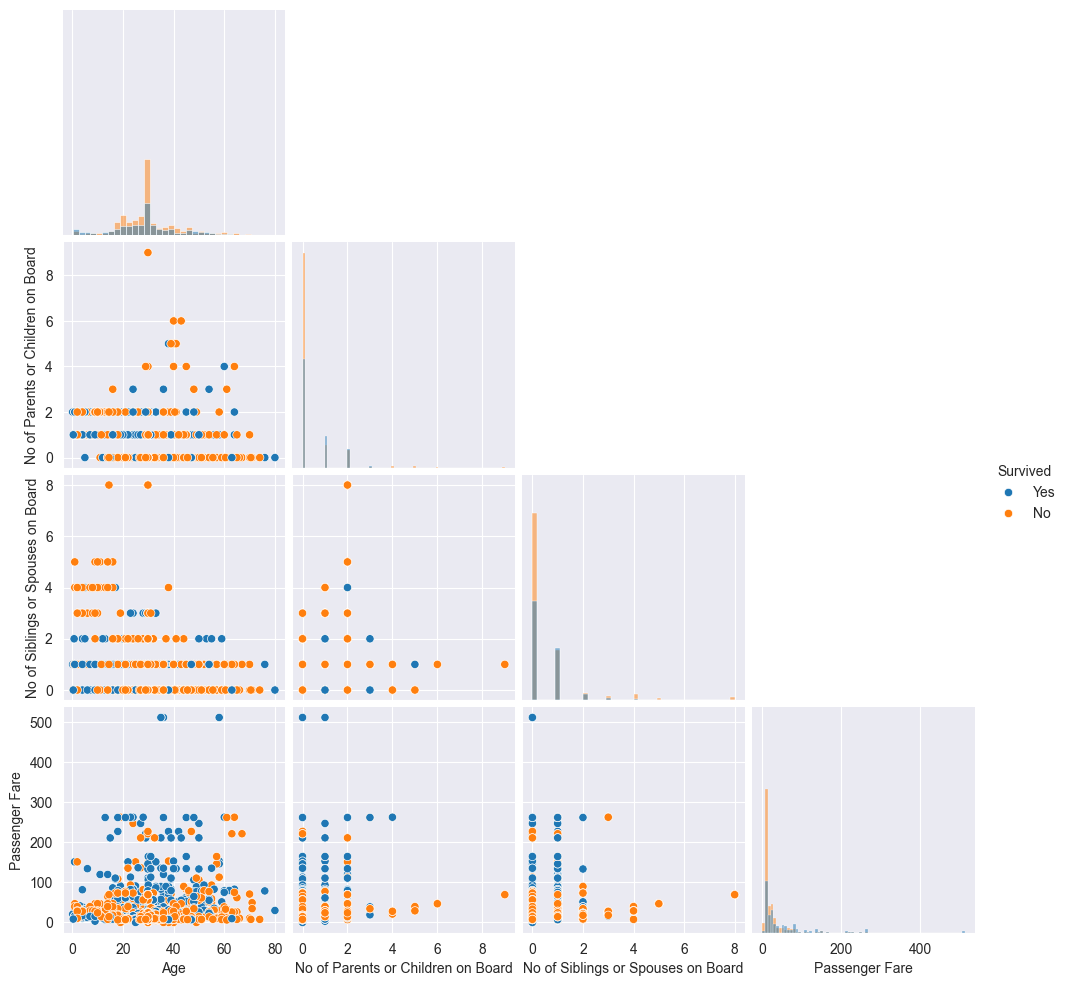

In [145]:
g = sns.pairplot(data=df,
            hue="Survived",
            diag_kind="hist",
            corner=True)

In [146]:
Gender_Survived = pd.crosstab(df["Sex"],
            df["Survived"],
            normalize="index")*100
Gender_Survived.round(1)

Survived,No,Yes
Sex,,
Female,27.3,72.7
Male,80.9,19.1


* Observation: 여성의 생존률 약 72.7% , 남성의 생존률 약 19.1%

<Axes: xlabel='Survived', ylabel='count'>

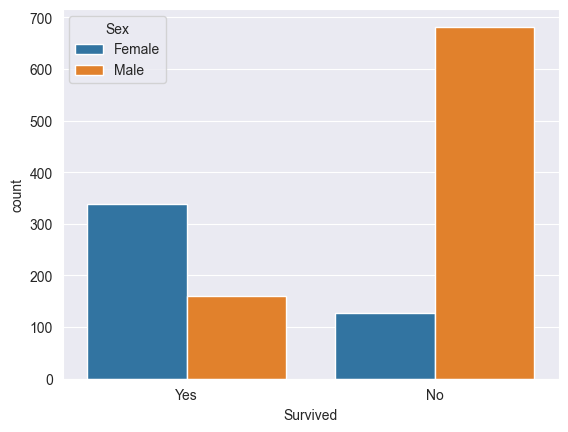

In [147]:
sns.countplot(data=df,
            x="Survived",
            hue="Sex"
            )

<Axes: xlabel='Age', ylabel='Count'>

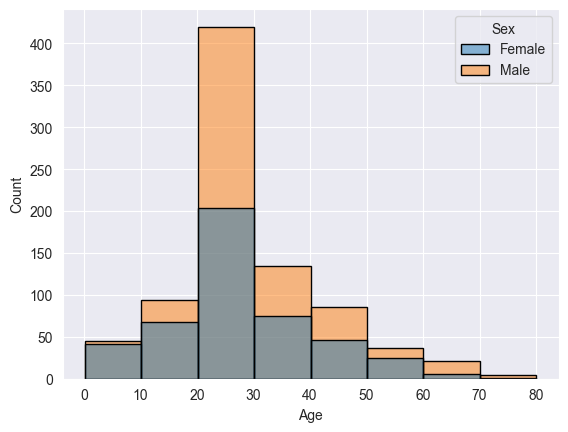

In [148]:
sns.histplot(data=df,
            x="Age",
            bins=8,
            hue="Sex",
            edgecolor="black")

* Observation: 20대가 약 600명으로 제일 많고 전체연령대에서 여자보다 남자가 더 많다.

<Axes: xlabel='Survived', ylabel='Age'>

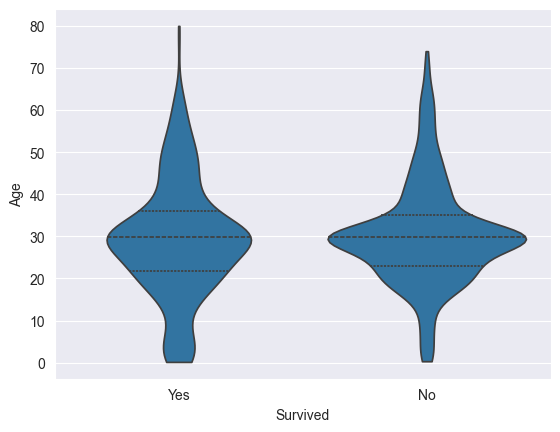

In [149]:
sns.violinplot(data=df,
                x="Survived",
                y="Age",
                inner="quart",
                cut=0)

<Axes: xlabel='Survived', ylabel='Passenger Fare'>

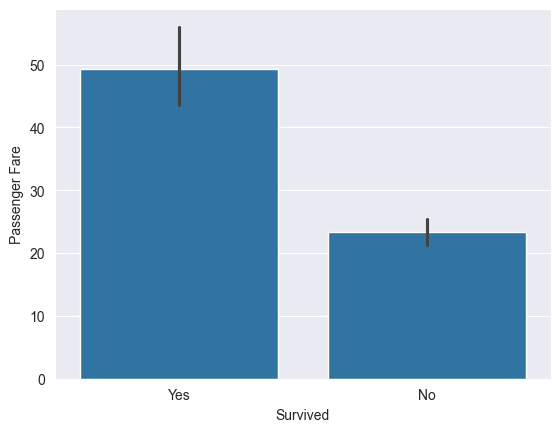

In [150]:
sns.barplot(data=df,
            x="Survived",
            y="Passenger Fare")

* Observation: 생존한 사람들의 평균 지불한 요금은 생존하지 못한 사람들의 평균 지불한 요금보다 높다.

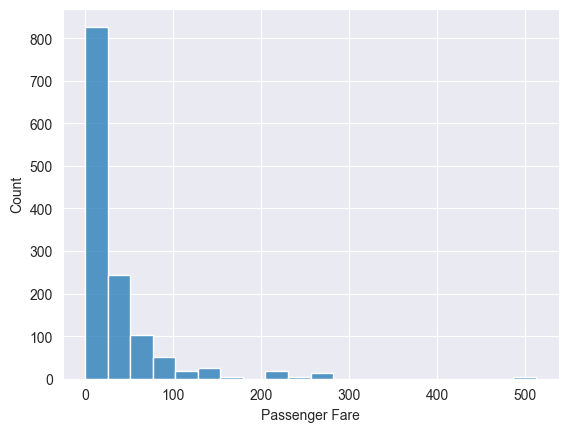

In [160]:
fare_counts = (
    df.groupby("Passenger Fare")
    .size()
    .reset_index(name="Passenger Count")
)

sns.histplot(data=df, x="Passenger Fare", bins=20)
plt.show()